In [ ]:
import numpy as np
import pandas as pd
import pickle
import joblib
from scipy.sparse import csr_matrix # Assuming tfidf_matrix is a sparse matrix
from google.colab import drive
drive.mount('/content/drive')


BASE_FILE_PATH = '/content/drive/MyDrive/dblp-ref/'
# Define file paths (adjust these if your files are in a different location)
PARQUET_FILE = BASE_FILE_PATH + 'dblp_preprocessed.parquet'
TFIDF_MATRIX = BASE_FILE_PATH + 'tfidf_matrix.pkl'
TFIDF_VECTORIZER = BASE_FILE_PATH + 'tfidf_vectorizer.pkl'

X = pd.read_parquet(PARQUET_FILE)
X_tfidf = joblib.load(TFIDF_MATRIX)
V_tfidf = joblib.load(TFIDF_VECTORIZER)

display(X.head())

Mounted at /content/drive


,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",-0.223340,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,0.669529,00127ee2-cb05-48ce-bc49-9de556b93346,preliminary design of a network protocol learn...,2.764640,...,-0.267190,-0.305477,-0.136099,-0.090603,0.082991,-0.316415,-0.293604,0.112798,-0.413274,0.081158
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",0.093716,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,0.413662,001c58d3-26ad-46b3-ab3a-c1e557d16821,a methodology for the physically accurate visu...,-0.605276,...,0.893701,-0.472392,0.589560,-0.673034,-0.610204,-0.471977,-0.172192,-0.003315,-0.867900,-0.438335
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",0.093716,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,0.157794,001c8744-73c4-4b04-9364-22d31a10dbf1,comparison of garch neural network and support...,0.518029,...,-0.454386,-0.210310,-0.160133,0.212752,-0.137549,-0.134914,-0.313803,0.213007,0.046193,0.265358
3,,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",-0.223340,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,0.413662,00338203-9eb3-40c5-9f31-cbac73a519ec,development of remote monitoring and control d...,1.079682,...,-0.527497,0.438907,-0.479178,-0.475394,-0.597755,-1.017956,-0.227117,0.541668,0.315353,0.213414
4,,"[Giovanna Guerrini, Isabella Merlo]",-0.210658,[],Reasonig about Set-Oriented Methods in Object ...,,-1.249479,0040b022-1472-4f70-a753-74832df65266,reasonig about set oriented methods in object ...,-0.605276,...,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079


### Topic Extraction with NMF
Let's use Non-Negative Matrix Factorization (NMF) to extract topics from the TF-IDF matrix.

In [ ]:
from sklearn.decomposition import NMF

# Set the number of topics you want to extract
n_topics = 25

# Initialize and fit the NMF model
nmf_model = NMF(n_components=n_topics, random_state=42, init='nndsvd')
W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

print("NMF model fitted successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NMF model fitted successfully!


Now, let's look at the top words representing each topic:

In [ ]:
def display_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]))

# Extract feature names (words) from the vectorizer
tfidf_feature_names = V_tfidf.get_feature_names_out()

# Display the top 10 words for each topic
display_topics(nmf_model, tfidf_feature_names, 20)

Topic 0:
problem problems linear method solution equations functions numerical finite order optimization function programming methods optimal solutions solving nonlinear set matrix
Topic 1:
networks network wireless sensor routing neural nodes traffic protocol node hoc ad energy communication packet protocols communications distributed layer topology
Topic 2:
information knowledge social systems research management user study technology users design retrieval use support online business computer process decision science
Topic 3:
image images segmentation color processing retrieval visual resolution imaging registration vision object reconstruction using based compression method texture wavelet medical
Topic 4:
algorithm algorithms search optimization genetic problem evolutionary clustering proposed based scheduling efficient swarm optimal adaptive tree new objective fast particle
Topic 5:
learning students machine education neural reinforcement training teaching online student educatio

### Visualizing Topic Clusters

To visualize how documents group into the extracted topics, we can use dimensionality reduction techniques like t-Distributed Stochastic Neighbor Embedding (t-SNE). This allows us to represent the high-dimensional document-topic distributions in a 2D space, where each point represents a document and its color indicates its most dominant topic.

In [ ]:
from umap import UMAP

reducer = UMAP()

X_umap = reducer.fit_transform(W)



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


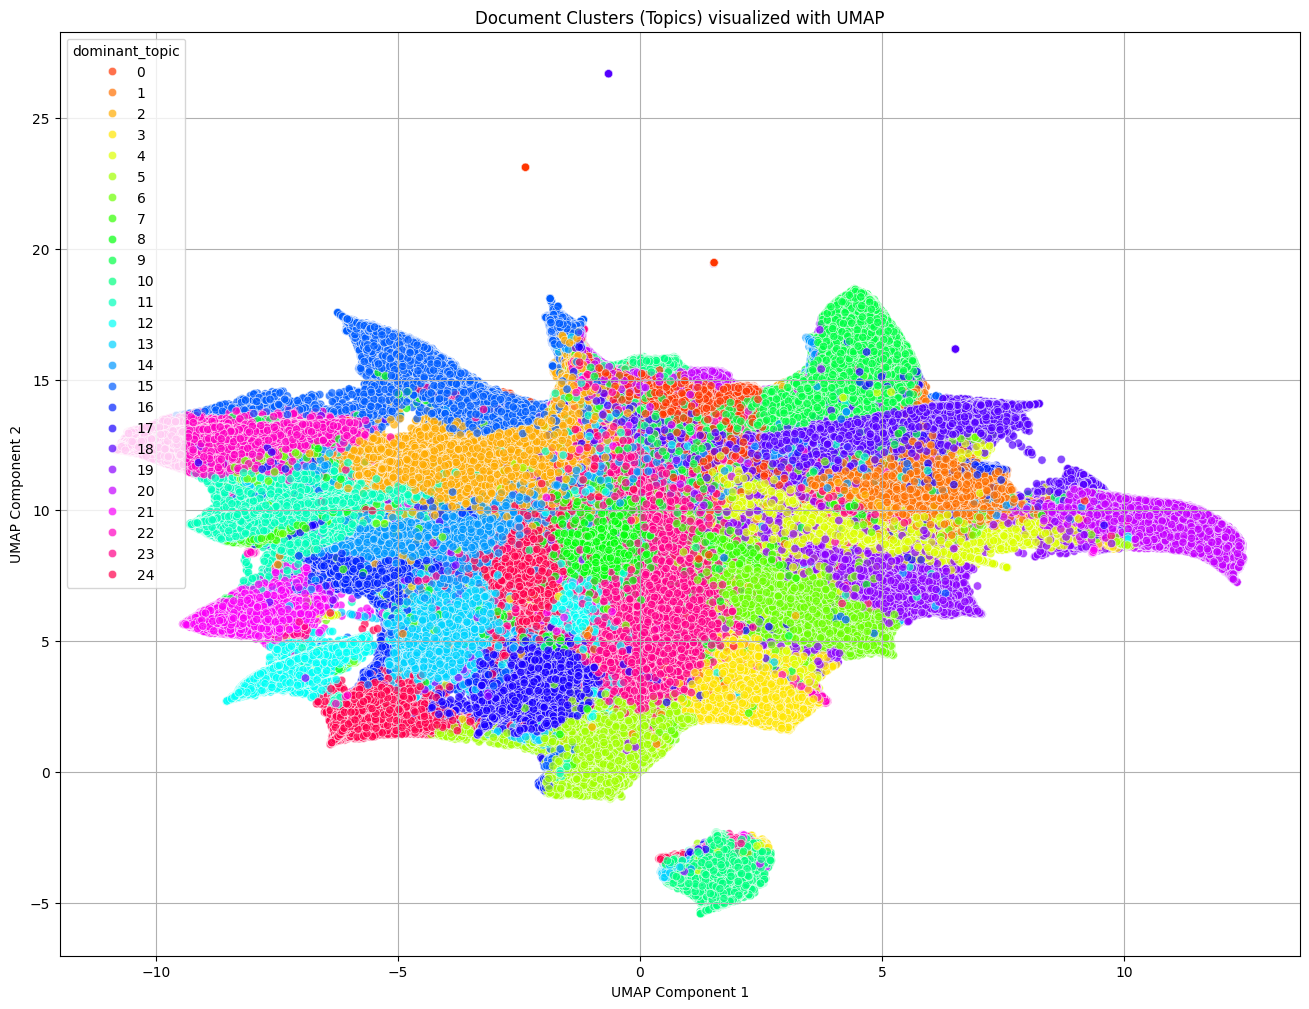

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get the dominant topic for each document from the NMF results (W)
dominant_topics = np.argmax(W, axis=1)

# Create a DataFrame for plotting the UMAP results
df_umap = pd.DataFrame({
    'umap-x': X_umap[:, 0],
    'umap-y': X_umap[:, 1],
    'dominant_topic': dominant_topics
})

plt.figure(figsize=(16, 12))
sns.scatterplot(
    x="umap-x", y="umap-y",
    hue="dominant_topic",
    palette=sns.color_palette("hsv", n_topics),
    data=df_umap,
    legend="full",
    alpha=0.7
)
plt.title('Document Clusters (Topics) visualized with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

### Preparing Data for Semi-Supervised Learning

We will extract a few highly representative documents for each cluster and assign them labels to bootstrap a semi-supervised learning algorithm. The rest will remain unlabeled (represented by `-1`).

In [ ]:
import numpy as np

# Set how many documents to label per topic
n_labeled_per_topic = 1000

# Initialize a labels array with -1 (standard for unlabeled data in sklearn)
semi_supervised_labels = np.full(W.shape[0], -1)

# Iterate over each topic to find the most representative documents
for topic_idx in range(n_topics):
    # Sort documents by their weight for the current topic in descending order
    top_doc_indices = np.argsort(W[:, topic_idx])[::-1][:n_labeled_per_topic]

    # Assign the topic index as the label for these top documents
    semi_supervised_labels[top_doc_indices] = topic_idx

# Add the labels to our DataFrame for tracking
df_umap['ssl_label'] = semi_supervised_labels

# Verify the counts
total_docs = len(df_umap)
labeled_docs = np.sum(semi_supervised_labels != -1)
unlabeled_docs = np.sum(semi_supervised_labels == -1)

print(f"Total documents: {total_docs}")
print(f"Labeled documents: {labeled_docs}")
print(f"Unlabeled documents: {unlabeled_docs}")

Total documents: 3079007
Labeled documents: 24995
Unlabeled documents: 3054012


# Topics

Topic 0: Numerical Methods

Topic 1: Networking

Topic 2: Information Systems, Business

Topic 3: Digital Image Processing

Topic 4: Algorithms & Data Structures

Topic 5: Machine Learning

Topic 6: Data Science

Topic 7: Search Engine, Semantics

Topic 8: Statistical Modeling

Topic 9: Signal Processing

Topic 10: Fuzzy logic

Topic 11: Cloud Infrastructure

Topic 12: Speech/Face Recognition

Topic 13: Control Systems

Topic 14: Power

Topic 15: Software Engineering Principles

Topic 16: Mobile

Topic 17: Agentic AI

Topic 18: Performance

Topic 19: Scheduling

Topic 20: Graphing

Topic 21: Video Processing

Topic 22: CyberSec

Topic 23: Classification

Topic 24: Robotics

In [ ]:
numerical_methods = df_umap[df_umap['ssl_label'] == 0]

numerical_methods.head()

,umap-x,umap-y,dominant_topic,ssl_label
14846,2.712818,12.751444,0,0
29755,2.560021,13.167704,0,0
36043,2.569995,13.176239,0,0
46288,2.266575,11.993726,0,0
78978,2.555741,13.263830,0,0


In [ ]:
import gc

# Map the cluster indices back to the original dataset X
original_numerical_docs = X.loc[numerical_methods.index]

# Let's inspect the abstracts (and any other columns you have) for these top documents
display(original_numerical_docs.head())

del numerical_methods, original_numerical_docs
gc.collect()

,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
14846,An inverse problem of determination of a coeff...,"[Le Thi Hoai An, Pham Dinh Tao, Dinh Nho Hào]",-0.210658,"[540c1e0d-bd78-4547-bc80-49d3c42a2a9e, aae2cc2...",Solving an Inverse Problem for an Elliptic Equ...,Journal of Global Optimization,-0.609810,41ee93af-9466-498c-b337-433d876c1fa7,solving an inverse problem for an elliptic equ...,-0.043623,...,-0.951403,-0.326262,-1.372393,0.486499,-0.320965,1.313148,1.462991,-1.576257,-1.253898,0.911947
29755,In this paper the problem of finding the set o...,[Lubomir V. Kolev],0.049328,[242bf534-a584-41e6-aa37-84e90072cd4b],A New Method for Global Solution of Systems of...,Reliable Computing,-1.249479,990dd053-63e4-48cb-8941-e2534c7be714,a new method for global solution of systems of...,-1.166928,...,0.140964,0.072630,0.209779,1.036149,0.296968,0.816167,0.609356,-0.044344,-0.341858,-0.854872
36043,A method is presented for solving the finite n...,[Oscar Barrientos],-0.210658,[3e329127-3bb6-4295-93ad-bcfc579367da],A Global Regularization Method for Solving the...,Computational Optimization and Applications,-1.249479,673ae286-a755-4da2-93fb-1b68655f86ba,a global regularization method for solving the...,-1.166928,...,-0.107390,-0.091716,-0.633002,0.224323,0.146613,0.055969,-0.231453,0.423328,0.106006,0.514199
46288,"A method, called the method of pseudolinear eq...",[John E. Lavery],-0.223340,[968bc1c7-aa35-4f90-8205-ff6b62b187b5],Solution of quasilinear hyperbolic initial-bou...,Computing,-3.296421,6ed8821c-8207-4b57-b355-acce5c180f05,solution of quasilinear hyperbolic initial bou...,-1.166928,...,-0.281414,-0.087034,-0.681548,-0.428942,0.415760,-0.461996,-0.527484,0.357389,-0.045603,0.280708
78978,We introduce a class of algorithms for the sol...,"[Stephan Engelke, Christian Kanzow]",0.093716,"[084bce90-48c1-4870-ace0-ffca38af2496, 3898368...",On the Solution of Linear Programs by Jacobian...,Annals of Operations Research,-0.865677,f6b68562-d56a-4dff-881f-3f6ad00af749,on the solution of linear programs by jacobian...,-0.605276,...,-0.163430,0.454143,-0.071755,0.314425,-0.727097,0.529042,0.253780,-0.594885,-0.440383,0.619979


134239

In [ ]:
cloud = X.loc[df_umap[df_umap['ssl_label'] == 11].index]

display(cloud.head())

del cloud
gc.collect()

,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
25697,"In telecommunications, increasingly complex se...","[Jochen Wulf, Thorsten Hau, Ruediger Zarnekow,...",-0.210658,"[02168343-4b2a-4d76-bae3-23bcc4419d61, 0b1aca2...",Specifying Enabling Services in Telecommunicat...,,0.157794,63225f0f-c8f9-4a89-b4b3-877691ed71a4,specifying enabling services in telecommunicat...,0.518029,...,-0.016958,0.353586,-0.169518,-0.439837,-0.169054,-0.512837,-0.537286,0.244626,0.171994,0.014706
31315,One important challenge the Aniketos platform ...,"[Muhammad Asim, Artsiom Yautsiukhin, Achim D. ...",-0.216999,"[0608dff1-6e38-40ea-a67e-c87c67a0336d, 7611755...",Security Policy Monitoring of Composite Services,,0.797463,169dbb72-f793-47d6-aa80-630b95ba1332,security policy monitoring of composite servic...,1.079682,...,-0.229383,0.320418,-0.362539,-0.594953,-0.200133,-0.554826,-0.602007,0.350035,0.129352,0.000480
32416,Web services architectures have recently emerg...,"[Domenico Cotroneo, Cristiano di Flora, Stefan...",-0.166270,"[1011b5ea-800d-45bd-bf69-042fe2a18aef, 1219d39...",An enhanced service oriented architecture for ...,Journal of Web Engineering,-0.737743,5bb2524d-3436-4391-80bf-33ffdde8d359,an enhanced service oriented architecture for ...,-0.043623,...,-0.893697,0.881162,0.526288,-0.499182,-0.634375,-0.179764,-0.234891,0.123395,-0.305441,-0.026104
33115,Many services and service providers compete wi...,"[Surya Nepal, Wanita Sherchan, Athman Bouguett...",0.093716,"[0697c62e-e770-410d-9004-5bbb2dab7179, 0cfbdcf...",Service Trust Management for E-Government Appl...,,0.797463,8fb667be-c558-48fe-bc13-97c6d8218702,service trust management for e government appl...,-0.043623,...,-0.252033,0.209866,-0.436432,-0.115828,-0.095036,-0.468074,-0.275835,0.289764,0.216860,0.259445
36587,,"[Koray Erek, Thorsten Proehl, Ruediger Zarnekow]",-0.216999,"[6402ebd1-4f9f-46e1-8ea5-0e6f357a4132, a674cd4...",Managing Cloud Services with IT Service Manage...,,0.797463,9043d225-53ec-4598-b9c6-33607a82c6bf,managing cloud services with it service manage...,-0.043623,...,-0.610082,0.389501,-0.141219,-0.365456,-0.294024,-0.372471,-0.424981,0.349018,-0.290386,-0.139921


7448

In [ ]:
agentic = X.loc[df_umap[df_umap['ssl_label'] == 17].index]

display(agentic.head())

del agentic
gc.collect()

,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
3003,This chapter deals with performance issues in ...,"[Mario Kusek, Kresimir Jurasovic, Ignac Lovrek...",-0.223340,"[041af6e6-7cd2-42e9-ac24-ea8c3625953d, 07a2f9b...",Performance Models for Multi-agent Systems and...,,0.285728,004807f4-fe05-40e9-a557-a760f02dd956,performance models for multi agent systems and...,1.079682,...,-0.255666,-0.342573,-0.336776,-0.311372,0.078275,-0.298971,-0.212500,0.302400,0.493241,0.308948
4018,,"[D.C. Moura, Eugénio C. Oliveira]",-0.223340,"[27043473-e69d-4381-8201-224d01e2d432, 52f9d26...",Fighting Fire with Agents.,european workshop on multi-agent systems,-0.226008,28aa3340-0fad-43f9-b89d-35914cd00ae4,fighting fire with agents fighting fire with a...,-0.605276,...,-0.458935,0.677429,-0.206028,-0.383844,0.349390,-0.176759,-0.782737,0.223280,-0.311521,0.313275
4385,,"[Orlando Belo, José Neves]",-0.216999,[],Multi-Agent Systems Based Distributed Intellig...,,-1.633281,4662985d-2487-45e6-ab45-3fcd9da1e7d2,multi agent systems based distributed intellig...,-0.605276,...,-0.355962,0.094624,-0.236478,-0.411086,0.018843,-0.665444,-0.634950,0.169718,-0.244633,0.763255
4993,,"[Mirko Maleković, Mirko Cubrilo]",-0.223340,[],Incorporating Infatuation in Multi-Agent Systems,Journal of Advanced Computational Intelligence...,-0.226008,7509b699-8986-4d07-aff3-596c4141fa84,incorporating infatuation in multi agent syste...,-0.605276,...,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079
11503,,"[Gemma Bel Enguix, Maria Dolores Jiménez-López]",-0.223340,[],A Multi-Agent System Model of Dialogue.,european workshop on multi-agent systems,-0.353942,49deca54-26d6-4147-877a-4c622bd76131,a multi agent system model of dialogue a multi...,-0.605276,...,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079


0

In [ ]:
import joblib
import numpy as np


CLUSTER_PATH = BASE_FILE_PATH + "Clustering/"

# Save the UMAP and labels DataFrame
df_umap_path = CLUSTER_PATH + 'df_umap.parquet'
df_umap.to_parquet(df_umap_path)
print(f"Saved df_umap to {df_umap_path}")

# Save the NMF model
nmf_model_path = CLUSTER_PATH + 'nmf_model.pkl'
joblib.dump(nmf_model, nmf_model_path)
print(f"Saved NMF model to {nmf_model_path}")

# Save the W and H matrices from NMF
w_path = CLUSTER_PATH + 'nmf_W.npy'
np.save(w_path, W)
print(f"Saved W matrix to {w_path}")

h_path = CLUSTER_PATH + 'nmf_H.npy'
np.save(h_path, H)
print(f"Saved H matrix to {h_path}")

Saved df_umap to /content/drive/MyDrive/dblp-ref/Clustering/df_umap.parquet
Saved NMF model to /content/drive/MyDrive/dblp-ref/Clustering/nmf_model.pkl
Saved W matrix to /content/drive/MyDrive/dblp-ref/Clustering/nmf_W.npy
Saved H matrix to /content/drive/MyDrive/dblp-ref/Clustering/nmf_H.npy


In [ ]:
import numpy as np
import pandas as pd
import pickle
import joblib
from scipy.sparse import csr_matrix # Assuming tfidf_matrix is a sparse matrix
from google.colab import drive
drive.mount('/content/drive')


BASE_FILE_PATH = '/content/drive/MyDrive/dblp-ref/'
CLUSTER_PATH = BASE_FILE_PATH + "Clustering/"
# Define file paths (adjust these if your files are in a different location)
PARQUET_FILE = BASE_FILE_PATH + 'dblp_preprocessed.parquet'
TFIDF_MATRIX = BASE_FILE_PATH + 'tfidf_matrix.pkl'
TFIDF_VECTORIZER = BASE_FILE_PATH + 'tfidf_vectorizer.pkl'

X = pd.read_parquet(PARQUET_FILE)
X_tfidf = joblib.load(TFIDF_MATRIX)
V_tfidf = joblib.load(TFIDF_VECTORIZER)

display(X.head())

Mounted at /content/drive


,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",-0.223340,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,0.669529,00127ee2-cb05-48ce-bc49-9de556b93346,preliminary design of a network protocol learn...,2.764640,...,-0.267190,-0.305477,-0.136099,-0.090603,0.082991,-0.316415,-0.293604,0.112798,-0.413274,0.081158
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",0.093716,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,0.413662,001c58d3-26ad-46b3-ab3a-c1e557d16821,a methodology for the physically accurate visu...,-0.605276,...,0.893701,-0.472392,0.589560,-0.673034,-0.610204,-0.471977,-0.172192,-0.003315,-0.867900,-0.438335
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",0.093716,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,0.157794,001c8744-73c4-4b04-9364-22d31a10dbf1,comparison of garch neural network and support...,0.518029,...,-0.454386,-0.210310,-0.160133,0.212752,-0.137549,-0.134914,-0.313803,0.213007,0.046193,0.265358
3,,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",-0.223340,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,0.413662,00338203-9eb3-40c5-9f31-cbac73a519ec,development of remote monitoring and control d...,1.079682,...,-0.527497,0.438907,-0.479178,-0.475394,-0.597755,-1.017956,-0.227117,0.541668,0.315353,0.213414
4,,"[Giovanna Guerrini, Isabella Merlo]",-0.210658,[],Reasonig about Set-Oriented Methods in Object ...,,-1.249479,0040b022-1472-4f70-a753-74832df65266,reasonig about set oriented methods in object ...,-0.605276,...,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079


In [ ]:
df_umap_path = CLUSTER_PATH + 'df_umap.parquet'
nmf_model_path = CLUSTER_PATH + 'nmf_model.pkl'
w_path = CLUSTER_PATH + 'nmf_W.npy'
h_path = CLUSTER_PATH + 'nmf_H.npy'

df_umap = pd.read_parquet(df_umap_path)
nmf_model = joblib.load(nmf_model_path)
W = np.load(w_path)
H = np.load(h_path)

print("Successfully loaded df_umap, nmf_model, W, and H!")
display(df_umap.head())


Successfully loaded df_umap, nmf_model, W, and H!


,umap-x,umap-y,dominant_topic,ssl_label
0,-0.332385,0.674451,5,-1
1,1.030782,8.702583,6,-1
2,4.556381,9.291112,19,-1
3,-4.651358,5.321209,13,-1
4,-0.785592,11.319127,23,-1


### Semi-Supervised Classification
Now we can use the confidently labeled documents to train a classifier and predict topics for the rest of the dataset.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

labeled_mask = df_umap['ssl_label'] != -1
unlabeled_mask = df_umap['ssl_label'] == -1

print(f"Training on {labeled_mask.sum()} labeled documents...")

X_labeled = X_tfidf[labeled_mask.values]
y_labeled = df_umap.loc[labeled_mask, 'ssl_label'].values

X_train, X_val, y_train, y_val = train_test_split(X_labeled, y_labeled, test_size=0.2, random_state=42)

clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1)

clf.fit(X_train, y_train)

val_preds = clf.predict(X_val)
print("\nValidation Performance on Labeled Subset:")
print(classification_report(y_val, val_preds))


Training on 24995 labeled documents...

Validation Performance on Labeled Subset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       205
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       189
           3       1.00      1.00      1.00       233
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       203
           6       1.00      1.00      1.00       199
           7       1.00      1.00      1.00       221
           8       1.00      1.00      1.00       213
           9       1.00      1.00      1.00       208
          10       1.00      1.00      1.00       186
          11       1.00      1.00      1.00       202
          12       1.00      1.00      1.00       191
          13       1.00      1.00      1.00       206
          14       1.00      1.00      1.00       183
          15       1.00      1.00      1.00       202

In [ ]:
# Now, let's predict the topics for the unlabeled data
print(f"Predicting labels for {unlabeled_mask.sum()} unlabeled documents...")

X_unlabeled = X_tfidf[unlabeled_mask.values]
predicted_labels = clf.predict(X_unlabeled)

# Assign the predicted labels back to the dataframe
df_umap.loc[unlabeled_mask, 'predicted_topic'] = predicted_labels
# For the originally labeled ones, we can just keep their original ssl_label
df_umap.loc[labeled_mask, 'predicted_topic'] = df_umap.loc[labeled_mask, 'ssl_label']

print("Done! All documents now have a 'predicted_topic'.")
display(df_umap['predicted_topic'].value_counts())

Predicting labels for 3054012 unlabeled documents...
Done! All documents now have a 'predicted_topic'.


,count
predicted_topic,
0.0,472005
2.0,344849
8.0,214134
23.0,208263
1.0,168488
4.0,155514
6.0,152582
14.0,121832
18.0,120037


Overall Agreement between Clustering and Classification: 73.89%



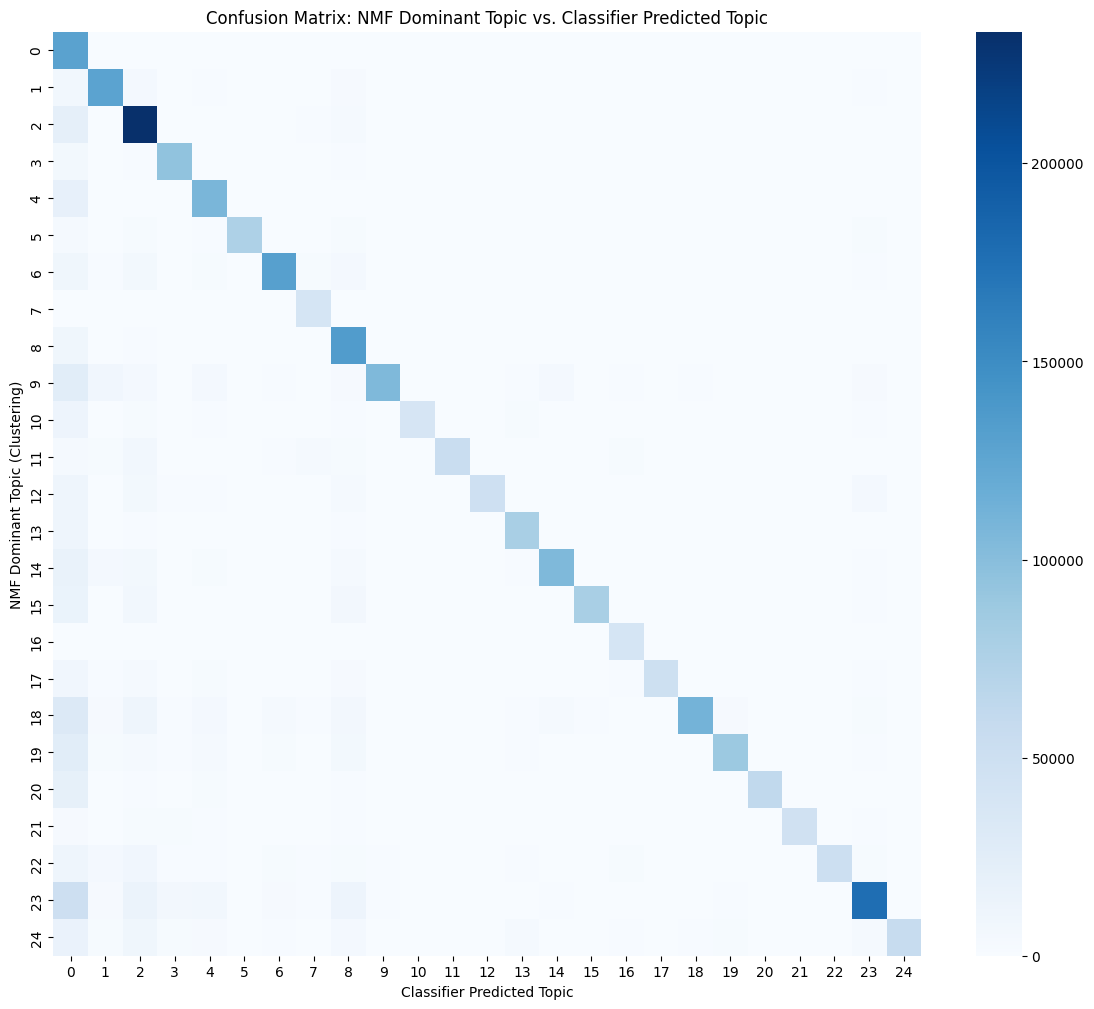

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

df_umap['predicted_topic'] = df_umap['predicted_topic'].astype(int)

# Calculate overall agreement
agreement_mask = df_umap['dominant_topic'] == df_umap['predicted_topic']
overall_agreement = agreement_mask.mean()
print(f"Overall Agreement between Clustering and Classification: {overall_agreement:.2%}\n")

# Create a confusion matrix
cm = confusion_matrix(df_umap['dominant_topic'], df_umap['predicted_topic'])

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title('Confusion Matrix: NMF Dominant Topic vs. Classifier Predicted Topic')
plt.xlabel('Classifier Predicted Topic')
plt.ylabel('NMF Dominant Topic (Clustering)')
plt.show()

In [ ]:
# Create a mask for documents where the models disagreed
disagreement_mask = df_umap['dominant_topic'] != df_umap['predicted_topic']

# Filter the dataframe
disagreements_df = df_umap[disagreement_mask].copy()

# Combine with the original dataset X to see the actual document text (e.g., abstract)
# Since they share the same index, we can concatenate them directly
disagreed_docs = pd.concat([
    X.loc[disagreements_df.index],
    disagreements_df[['dominant_topic', 'predicted_topic']]
], axis=1)

print(f"Total documents with disagreed topics: {len(disagreed_docs)}")
print("Here is a sample of the documents where clustering and classification disagreed:")

# Display a few random examples
display(disagreed_docs[['abstract', 'dominant_topic', 'predicted_topic']].sample(5))


Total documents with disagreed topics: 804035
Here is a sample of the documents where clustering and classification disagreed:


,abstract,dominant_topic,predicted_topic
2698400,Global optimization is a long-lasting research...,4,0
2581768,"In this paper, we propose an unsupervised appr...",19,5
1645756,"In this paper, crucial aspects of the implicat...",17,0
446078,We consider an object buried in an inhomogeneo...,12,0
2211683,Active probe is the main method for Internet e...,23,18


In [ ]:
import joblib
import json

df_umap_labeled_path = CLUSTER_PATH + 'df_umap_labeled.parquet'
df_umap.to_parquet(df_umap_labeled_path)
print(f"Saved updated df_umap to {df_umap_labeled_path}")

clf_path = CLUSTER_PATH + 'sgd_classifier.pkl'
joblib.dump(clf, clf_path)
print(f"Saved SGDClassifier to {clf_path}")

topic_mapping = {
    0: "Numerical Methods", 1: "Networking", 2: "Information Systems, Business",
    3: "Digital Image Processing", 4: "Algorithms & Data Structures", 5: "Machine Learning",
    6: "Data Science", 7: "Search Engine, Semantics", 8: "Statistical Modeling",
    9: "Signal Processing", 10: "Fuzzy logic", 11: "Cloud Infrastructure",
    12: "Speech/Face Recognition", 13: "Control Systems", 14: "Power",
    15: "Software Engineering Principles", 16: "Mobile", 17: "Agentic AI",
    18: "Performance", 19: "Scheduling", 20: "Graphing", 21: "Video Processing",
    22: "CyberSec", 23: "Classification", 24: "Robotics"
}

topic_mapping_path = CLUSTER_PATH + 'topic_mapping.json'
with open(topic_mapping_path, 'w') as f:
    json.dump(topic_mapping, f)
print(f"Saved topic mapping to {topic_mapping_path}")

Saved updated df_umap to /content/drive/MyDrive/dblp-ref/Clustering/df_umap_labeled.parquet
Saved SGDClassifier to /content/drive/MyDrive/dblp-ref/Clustering/sgd_classifier.pkl
Saved topic mapping to /content/drive/MyDrive/dblp-ref/Clustering/topic_mapping.json
